This is the Jupyter Notebook for the Data analysis and implementation for Fatigue Life Prediction of polymer matrix composites using a Physics informed neural network 

*A physics-informed neural network based on the self-heating effect for fatigue life prediction of polymer matrix composites*

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.neighbors import KernelDensity
from scipy.stats import beta
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import torch 
import torch.optim as optim 
import torch.nn as nn 

In [2]:
np.random.seed(42)

With the increasing use of polymer matrix composites (PMCs) across different engineering applications, there is more focus on their durability under cyclic loading conditions. Consequently, large efforts have been made for accurate and reliable fatigue life models that encompass the complexity of composite materials within a short time frame. This investigation employs a physics-informed neural network (PINN) with the self-heating behavior of PMCs embedded as soft physics constraints to predict fatigue life of different PMCs reported in literature. This model is applied to different PMCs loaded under cyclic loading conditions and results show that fatigue life can be predicted using load levels and stabilized surface temperature with reasonable accuracy even for PMCs that exhibit scatter.

We are working with the data from the Huang paper, "A new model for fatigue life prediction based on infrared thermography and degradation process for CFRP compositie laminates" 

We collected, Temp vs stress and stress vs Number of cycles data. 
The idea is to build a simple PINN model to facilitate fatigue life predictions with physics loss terms i.e stress monotononicity and temp monotonicity 

The pipeline is divided into modules. The first part deals with the stress vs temp dataset, and the second part deals with the stress, temp vs number of cycles i.e the implementation of PINN. The pipeline is structured in the following way:
1.  The first module involves developing a regression model to evaluate the self-heating temperatures of Polymer Matrix Composites, which are required as an input for the subsequent fatigue-life prediction from the given stress values.
2. Module 2 consists of augmenting fatigue life data. For this purpose, the original dataset is split into training and testing sets based on the k-fold cross-validation technique. The data available for training are then augmented using Basquin curve fitting and the MCS approach.
3.  In Module 3 the trained XG-Boost model is used to predict the stabilized surface temperature for the corresponding augmented stress level, which is then used as a combined input data/feature map to predict fatigue lives at load levels above the fatigue strength of PMCs. Subsequently, a PINN model, which uses both physics-based and data-driven loss functions for evaluation, is then trained to predict the fatigue life of PMCs.

Importing Temperature vs Stress data. We will first start by checking and importing data collected through real experiments and see how it is.

In [ ]:
file = r"TempvsStress.xlsx"

df_one = pd.read_excel(file)

df_one

,Stab Temp(degree C),Maximum stress(%UTS),Material
0,1.262,29.851,Triaxially braided CFRP Laminates
1,1.461,34.879,Triaxially braided CFRP Laminates
2,2.145,39.825,Triaxially braided CFRP Laminates
3,2.694,44.928,Triaxially braided CFRP Laminates
4,3.567,50.108,Triaxially braided CFRP Laminates
5,4.251,54.818,Triaxially braided CFRP Laminates
6,5.258,59.997,Triaxially braided CFRP Laminates
7,6.482,65.095,Triaxially braided CFRP Laminates
8,8.029,70.270,Triaxially braided CFRP Laminates
9,10.222,75.125,Triaxially braided CFRP Laminates


In [4]:
df_one = df_one.drop([0,1,2,3,4,5,6,7,8,9,10,11]).reset_index(drop=True)
df_one

,Stab Temp(degree C),Maximum stress(%UTS),Material
0,0.050,29.931,UD CFRP based
1,0.107,34.814,UD CFRP based
2,0.108,39.854,UD CFRP based
3,0.165,45.131,UD CFRP based
4,0.221,50.093,UD CFRP based
5,0.285,54.898,UD CFRP based
6,0.363,60.175,UD CFRP based
7,0.525,65.140,UD CFRP based
8,0.651,69.868,UD CFRP based
9,1.072,75.155,UD CFRP based


Adding necessary feature columns such as UTS value and Maximum stress calculated from UTS and %UTS 

In [5]:
df_one["UTS"] = 1487.8
df_one["Maximum stress"] = (df_one["UTS"] * df_one["Maximum stress(%UTS)"]) / 100
df_one

,Stab Temp(degree C),Maximum stress(%UTS),Material,UTS,Maximum stress
0,0.050,29.931,UD CFRP based,1487.8,445.313418
1,0.107,34.814,UD CFRP based,1487.8,517.962692
2,0.108,39.854,UD CFRP based,1487.8,592.947812
3,0.165,45.131,UD CFRP based,1487.8,671.459018
4,0.221,50.093,UD CFRP based,1487.8,745.283654
5,0.285,54.898,UD CFRP based,1487.8,816.772444
6,0.363,60.175,UD CFRP based,1487.8,895.283650
7,0.525,65.140,UD CFRP based,1487.8,969.152920
8,0.651,69.868,UD CFRP based,1487.8,1039.496104
9,1.072,75.155,UD CFRP based,1487.8,1118.156090


Splitting the data into training and testing for the first part of our ML/DL Pipeline.
We do a 50-50 random split based on our domain knowledge of data distribution 

In [6]:
train_dfone = df_one.sample(frac = 0.5, random_state=42)
test_dfone = df_one.drop(train_dfone.index).reset_index(drop=True)
test_dfone

,Stab Temp(degree C),Maximum stress(%UTS),Material,UTS,Maximum stress
0,0.107,34.814,UD CFRP based,1487.8,517.962692
1,0.165,45.131,UD CFRP based,1487.8,671.459018
2,0.221,50.093,UD CFRP based,1487.8,745.283654
3,0.363,60.175,UD CFRP based,1487.8,895.283650
4,0.525,65.140,UD CFRP based,1487.8,969.152920
5,1.639,80.288,UD CFRP based,1487.8,1194.524864
6,4.033,90.272,UD CFRP based,1487.8,1343.066816


The following scatter plot shows the how the Temperature vs Stress curve looks like for the data

<>:12: SyntaxWarning: invalid escape sequence '\D'
<>:12: SyntaxWarning: invalid escape sequence '\D'
/var/folders/dl/_w72qrpj6gs0p_2yyrq_pcdr0000gn/T/ipykernel_11736/3474892996.py:12: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("$\Delta T_{stab}$ (°C)")


[]

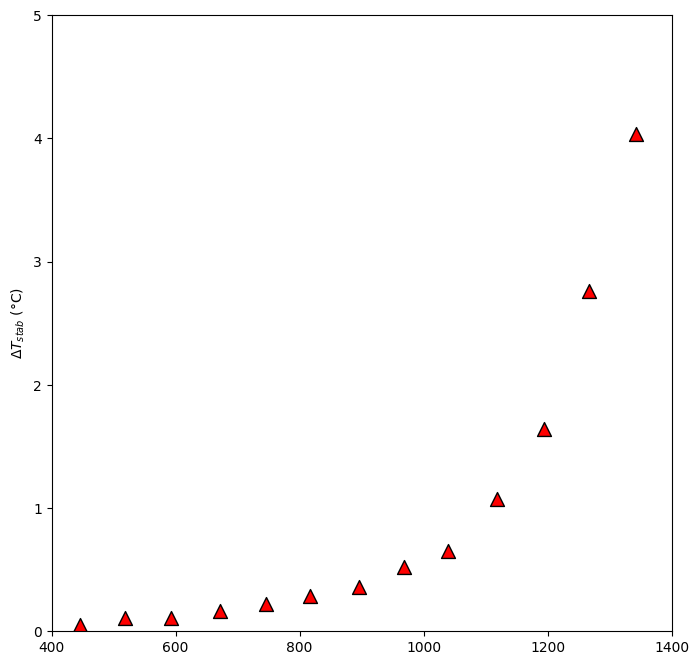

In [7]:
train_dfone = train_dfone.reset_index(drop=True)
row_to_move = test_dfone.loc[[6]]
train_dfone = pd.concat([train_dfone, row_to_move],ignore_index=True)
test_dfone = test_dfone.drop(6)
train_dfone

plt.figure(figsize=(8, 8))
plt.scatter(df_one["Maximum stress"], df_one["Stab Temp(degree C)"],c='red', marker='^', s=100, edgecolors='k')
plt.ylim(0, 5)
plt.xlim(400, 1400)
plt.fontsize = 18
plt.ylabel("$\Delta T_{stab}$ (°C)")
plt.plot()

In [8]:
train_dfone.columns

Index(['Stab Temp(degree C)', 'Maximum stress(%UTS)', 'Material', 'UTS',
       'Maximum stress'],
      dtype='object')

In [9]:
delta_fl = 72.5

Data augmentation is a technique used to artificially increase the size and diversity of a training dataset by applying various transformations to existing data samples. This helps to improve the performance and generalization ability of machine learning models, particularly when dealing with limited or imbalanced datasets

We augment our data based on finding the right curve fiting of the datapoints. We induce a slight noise to the points and thus get a distribution even where there is not enough data. Following is the function to carry out the data augmentation process 

<>:84: SyntaxWarning: invalid escape sequence '\D'
<>:84: SyntaxWarning: invalid escape sequence '\D'
/var/folders/dl/_w72qrpj6gs0p_2yyrq_pcdr0000gn/T/ipykernel_11736/1290905376.py:84: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("$\Delta T_{stab}$ (°C)")


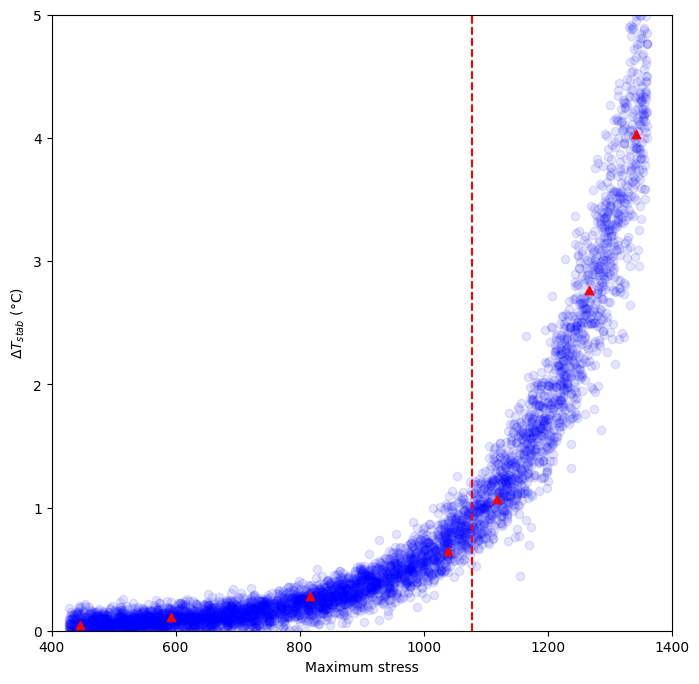

In [10]:
from scipy.optimize import curve_fit

def augment_SN_MC_global(
    train_SN,
    n_samples=5000,
    noise_level=0.15,  
    rng_seed=42
):
    rng = np.random.default_rng(rng_seed)
    
    s_real = train_SN["Maximum stress(%UTS)"].to_numpy(float)
    t_real = train_SN["Stab Temp(degree C)"].to_numpy(float)
    

    def physics_model(x, a, b, c):
        return a * np.exp(b * x) + c

    p0 = [0.01, 0.05, 0] 
    
    try:
        popt, _ = curve_fit(physics_model, s_real, t_real, p0=p0, maxfev=10000)
    except RuntimeError:
        print("Exponential fit failed, falling back to Polynomial (deg 3)")
        z = np.polyfit(s_real, t_real, 3)
        physics_model = lambda x, *args: np.polyval(z, x)
        popt = []

    #Monte Carlo Simulation
    s_min, s_max = s_real.min(), s_real.max()
    s_range = s_max - s_min
    mc_stress = rng.uniform(s_min - 0.02*s_range, s_max + 0.02*s_range, n_samples)
    
    if len(popt) > 0:
        mc_temp_mean = physics_model(mc_stress, *popt)
    else:
        mc_temp_mean = physics_model(mc_stress)

    
    abs_noise = 0.05 
    rel_noise = mc_temp_mean * noise_level 
    
    sigma_noise = abs_noise + rel_noise
    
    mc_temp = mc_temp_mean + rng.normal(0, sigma_noise)
    
    mc_temp = np.maximum(mc_temp, 0.0) 
    mc_stress = np.maximum(mc_stress, 0.0)
    aug = pd.DataFrame({
        "Maximum stress(%UTS)": mc_stress,
        "Maximum stress": (mc_stress * 1487.8) / 100,
        "Temp stabilisation":   mc_temp,
        "Source":               "augmented_MC",
        "sample_weight":        np.ones(n_samples)
    })
    
    real = pd.DataFrame({
        "Maximum stress(%UTS)": s_real,
        "Maximum stress": (s_real * 1487.8) / 100,
        "Temp stabilisation":   t_real,
        "Source":               "real",
        "sample_weight":        np.ones(len(s_real))
    })
    
    combined = pd.concat([aug, real], ignore_index=True)
    
    return combined, aug, real, popt


combined_df, aug_df, real_df, params = augment_SN_MC_global(train_dfone, n_samples=5000, noise_level=0.12)

plt.figure(figsize=(8, 8))
plt.scatter(aug_df["Maximum stress"], aug_df["Temp stabilisation"], 
            c='blue', alpha=0.1, label='MC Augmented (Global)')
plt.scatter(real_df["Maximum stress"], real_df["Temp stabilisation"], 
            c='red', marker = '^', label='Train Real')

# Plot the fitted trendline
# x_trend = np.linspace(real_df["Maximum stress(%UTS)"].min(), real_df["Maximum stress(%UTS)"].max(), 100)
# def func(x, a, b, c): return a * np.exp(b * x) + c
# if len(params) > 0:
#     plt.plot(x_trend, func(x_trend, *params), 'b--', label="fitted trend")

plt.xlabel("Maximum stress")
plt.ylabel("$\Delta T_{stab}$ (°C)")
plt.ylim(0, 5)
plt.xlim(400, 1400)
plt.axvline((delta_fl* 1487.8) / 100, color="red", ls="--", label="Fatigue strength")
#plt.title("Monte Carlo Augmentation")
#plt.legend()
plt.show()

The above graph gives us a good visualisation for how the augmented data looks like

In [11]:
combined_df

,Maximum stress(%UTS),Maximum stress,Temp stabilisation,Source,sample_weight
0,77.293513,1149.972889,1.118101,augmented_MC,1.0
1,56.265838,837.123145,0.207391,augmented_MC,1.0
2,82.605183,1228.999918,2.202287,augmented_MC,1.0
3,72.487260,1078.465448,0.804227,augmented_MC,1.0
4,34.634246,515.288305,0.055218,augmented_MC,1.0
...,...,...,...,...,...
5002,29.931000,445.313418,0.050000,real,1.0
5003,69.868000,1039.496104,0.651000,real,1.0
5004,54.898000,816.772444,0.285000,real,1.0
5005,39.854000,592.947812,0.108000,real,1.0


Final Distribution of the Augmented values plotted with the real values 

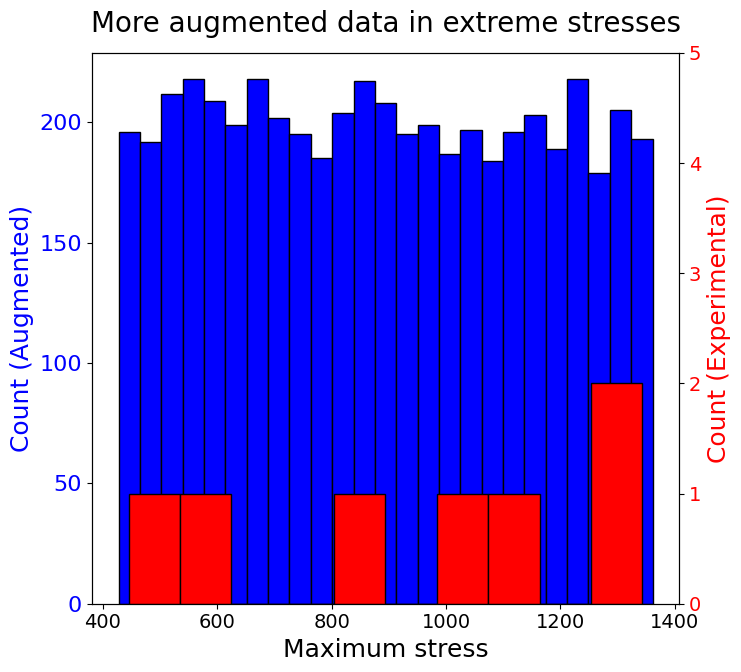

In [12]:

plt.rcParams.update({'font.size': 16})

fig, ax1 = plt.subplots(figsize=(8, 7))

ax1.hist(aug_df["Maximum stress"], bins=25, alpha=1,
         label="Augmented", color="b", edgecolor="k")
ax1.set_xlabel("Maximum stress", fontsize=18)
ax1.set_ylabel("Count (Augmented)", color="b", fontsize=18)
ax1.tick_params(axis='y', labelcolor='b')
ax1.tick_params(axis='x', labelsize=14)

ax2 = ax1.twinx()
ax2.hist(real_df["Maximum stress"], bins=10, alpha=1,
         label="Experimental", color="r", edgecolor="k")
ax2.set_ylabel("Count (Experimental)", color="r", fontsize=18)
ax2.tick_params(axis='y', labelcolor='r', labelsize=14)

plt.title("More augmented data in extreme stresses", fontsize=20, pad=15)
#fig.legend(loc="upper right", bbox_to_anchor=(1,1),
#           bbox_transform=ax1.transAxes, fontsize=14)

plt.tight_layout()
plt.ylim(0,5)
plt.show()

In [13]:
test_dfone.columns

Index(['Stab Temp(degree C)', 'Maximum stress(%UTS)', 'Material', 'UTS',
       'Maximum stress'],
      dtype='object')

We will now use this Augmented dataset to build an XGBoost Model that will predict Temperature for a given stress value. This model is important because a good prediction here will allow us to map these temperature values for the corresponding stress values in the stress vs number of cycles dataset 

In [14]:
test_dfone = test_dfone.rename(columns={"Stab Temp(degree C)":"Temp stabilisation"})
test_dfone

,Temp stabilisation,Maximum stress(%UTS),Material,UTS,Maximum stress
0,0.107,34.814,UD CFRP based,1487.8,517.962692
1,0.165,45.131,UD CFRP based,1487.8,671.459018
2,0.221,50.093,UD CFRP based,1487.8,745.283654
3,0.363,60.175,UD CFRP based,1487.8,895.283650
4,0.525,65.140,UD CFRP based,1487.8,969.152920
5,1.639,80.288,UD CFRP based,1487.8,1194.524864


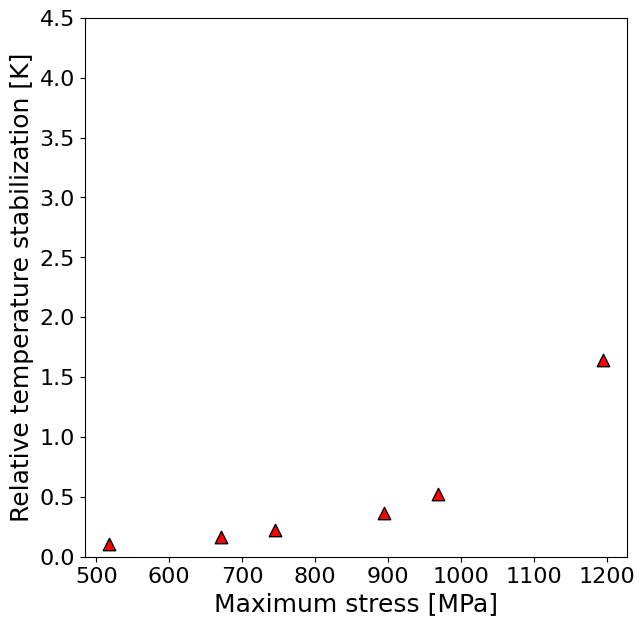

[]

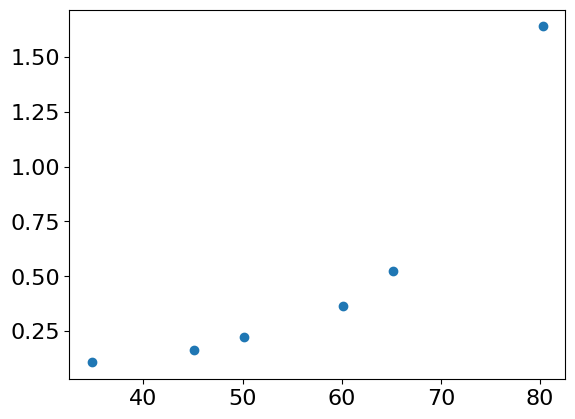

In [15]:
plt.figure(figsize=(7, 7))
plt.scatter(test_dfone["Maximum stress"], test_dfone["Temp stabilisation"],c='red', marker='^', s=80, edgecolors='k')
plt.xlabel('Maximum stress [MPa]', fontsize=18)
plt.ylabel('Relative temperature stabilization [K]', fontsize=18)
#plt.xlim(1e2,1e6)
#plt.yticks([1100, 1200, 1300, 1400])
plt.ylim(0, 4.5)
plt.show()



plt.scatter(test_dfone["Maximum stress(%UTS)"], test_dfone["Temp stabilisation"])
plt.plot()

The rapid growth of data science and computational power has led to the rise of machine learning (ML) as a powerful tool in various fields, including the modeling of composite materials . Machine learning also offers great potential for efficient and accurate prediction of the fatigue strength and life of composite materials. Linear regression, random forest regression, support vector regression, and artificial neural networks, among others, are commonly used ML-based regression algorithms for fatigue life prediction.

Defining the Input/Output features of the Model 

In [16]:
features = ["Maximum stress"]

X_train = combined_df[features]
X_test = test_dfone[features]
y_train = combined_df["Temp stabilisation"]
y_test = test_dfone["Temp stabilisation"]

Model Architecture of an XGBoost 

In [17]:
w_train = combined_df["sample_weight"].to_numpy()
model_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model_xgb.fit(X_train, y_train, sample_weight=w_train)
new_preds = model_xgb.predict(X_test)

r2 = r2_score(y_test, new_preds)
#As we can see, the r2 value is excellent. This allows us to use this model for our further predictions
print(r2)

0.9942193660714007


Following is the plot to show actual vs predicted for the trained model 

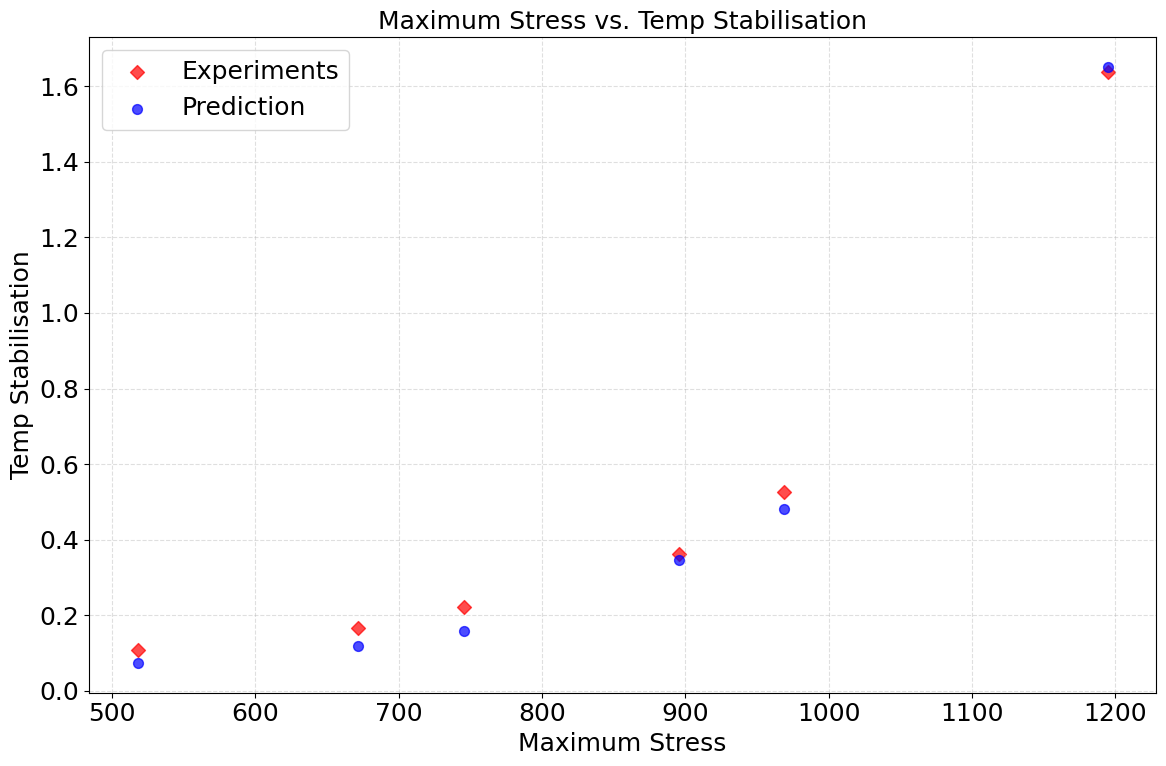

In [18]:
import matplotlib.pyplot as plt

plt.rc('font', size=18) 

plt.figure(figsize=(12, 8))

plt.scatter(
    X_test["Maximum stress"], 
    y_test, 
    color='red', 
    label='Experiments', 
    marker='D', 
    s=50,       
    alpha=0.7
)

plt.scatter(
    X_test["Maximum stress"], 
    new_preds, 
    color='blue', 
    label='Prediction', 
    marker='o', 
    s=50, 
    alpha=0.7
)

plt.title('Maximum Stress vs. Temp Stabilisation', fontsize=18)
plt.xlabel('Maximum Stress', fontsize=18)
plt.ylabel('Temp Stabilisation', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

As we can see, our approach to the augmentation with a curve fit allows us to predict values with a noise even in the scarcity of data points. This allows us to get a very good r2 value concluding our model building 

Importing our stress vs number of cycles dataset 

In [ ]:
file = r"StressvsNumberofcycles.xlsx"
df = pd.read_excel(file)
df 

,Maximum stress(%UTS),Number of cycles,Material
0,84.883,2299,Triaxially braided CFRP Laminates
1,80.220,12091,Triaxially braided CFRP Laminates
2,74.715,104718,Triaxially braided CFRP Laminates
3,69.939,1412534,Triaxially braided CFRP Laminates
4,64.983,5780372,Triaxially braided CFRP Laminates
5,95.008,647,UD CFRP based
6,94.792,711,UD CFRP based
7,95.084,1040,UD CFRP based
8,94.984,2317,UD CFRP based
9,94.808,2982,UD CFRP based


In [20]:
df = df.drop([0,1,2,3,4]).reset_index(drop=True)
df

,Maximum stress(%UTS),Number of cycles,Material
0,95.008,647,UD CFRP based
1,94.792,711,UD CFRP based
2,95.084,1040,UD CFRP based
3,94.984,2317,UD CFRP based
4,94.808,2982,UD CFRP based
5,90.024,2630,UD CFRP based
6,89.755,5311,UD CFRP based
7,90.050,6600,UD CFRP based
8,90.006,7276,UD CFRP based
9,89.945,19014,UD CFRP based


Adding necessary feature columns 

In [21]:
df["log cycles"] = np.log10(df["Number of cycles"])
df["UTS"] = 1487.8
df["Maximum stress"] = (df["UTS"] * df["Maximum stress(%UTS)"]) / 100
df

,Maximum stress(%UTS),Number of cycles,Material,log cycles,UTS,Maximum stress
0,95.008,647,UD CFRP based,2.810904,1487.8,1413.529024
1,94.792,711,UD CFRP based,2.851870,1487.8,1410.315376
2,95.084,1040,UD CFRP based,3.017033,1487.8,1414.659752
3,94.984,2317,UD CFRP based,3.364926,1487.8,1413.171952
4,94.808,2982,UD CFRP based,3.474508,1487.8,1410.553424
5,90.024,2630,UD CFRP based,3.419956,1487.8,1339.377072
6,89.755,5311,UD CFRP based,3.725176,1487.8,1335.374890
7,90.050,6600,UD CFRP based,3.819544,1487.8,1339.763900
8,90.006,7276,UD CFRP based,3.861893,1487.8,1339.109268
9,89.945,19014,UD CFRP based,4.279073,1487.8,1338.201710


The following scatter plot shows the how the S-N Curve looks like for the data

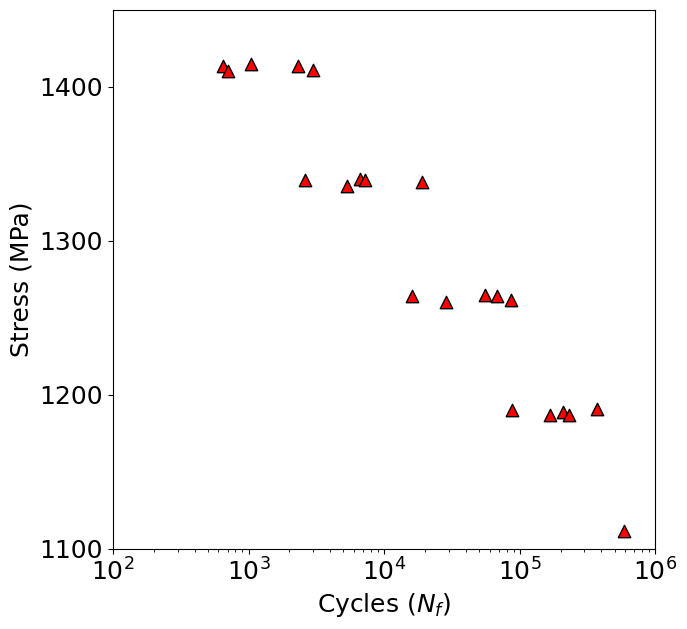

In [22]:
plt.figure(figsize=(7, 7))
plt.xscale('log')
plt.scatter(df["Number of cycles"], df["Maximum stress"],c='red', marker='^', s=80, edgecolors='k')
plt.xlabel('Cycles ($N_f$)', fontsize=18)
plt.ylabel('Stress (MPa)', fontsize=18)
plt.xlim(1e2,1e6)
plt.yticks([1100, 1200, 1300, 1400])
plt.ylim(1100, 1450)
plt.show()

In [23]:
delta_fl * 1487.8

107865.5

In [24]:
df["Source"] = "real"
df

,Maximum stress(%UTS),Number of cycles,Material,log cycles,UTS,Maximum stress,Source
0,95.008,647,UD CFRP based,2.810904,1487.8,1413.529024,real
1,94.792,711,UD CFRP based,2.851870,1487.8,1410.315376,real
2,95.084,1040,UD CFRP based,3.017033,1487.8,1414.659752,real
3,94.984,2317,UD CFRP based,3.364926,1487.8,1413.171952,real
4,94.808,2982,UD CFRP based,3.474508,1487.8,1410.553424,real
5,90.024,2630,UD CFRP based,3.419956,1487.8,1339.377072,real
6,89.755,5311,UD CFRP based,3.725176,1487.8,1335.374890,real
7,90.050,6600,UD CFRP based,3.819544,1487.8,1339.763900,real
8,90.006,7276,UD CFRP based,3.861893,1487.8,1339.109268,real
9,89.945,19014,UD CFRP based,4.279073,1487.8,1338.201710,real


Following is the function to plot out the derivatives graph. All of these helper plotting functions are utilised to build the necessary graphs to showcase how the predictions and results look like 

In [25]:
def check_derivatives(model, scaler, device):
    """Visualizes if the model respects the physics constraint (dLife/dStress < 0)"""
    stress_range = np.linspace(200, 600, 100).reshape(-1, 1)
    temp_range = np.zeros_like(stress_range) 
    
    X_grid = np.column_stack([stress_range, temp_range])
    X_grid_s = scaler.transform(X_grid)
    X_tensor = torch.tensor(X_grid_s, dtype=torch.float32, device=device, requires_grad=True)
    
    model.eval()
    logN_pred = model(X_tensor)
    grads = torch.autograd.grad(logN_pred, X_tensor, torch.ones_like(logN_pred), create_graph=True)[0]
    dLogN_dStress = grads[:, 0].cpu().detach().numpy() 
    
    plt.figure(figsize=(6, 4))
    plt.plot(stress_range, dLogN_dStress, color='purple', lw=2)
    plt.axhline(0, color='red', linestyle='--', label='Physics Limit (0)')
    plt.fill_between(stress_range.flatten(), dLogN_dStress, 0, where=(dLogN_dStress > 0), color='red', alpha=0.3, label='Violation')
    plt.fill_between(stress_range.flatten(), dLogN_dStress, 0, where=(dLogN_dStress < 0), color='green', alpha=0.1, label='Valid')
    plt.ylabel("Gradient (dLife/dStress)")
    plt.xlabel("Stress")
    plt.title("Physics Check: Is the derivative negative?")
    plt.legend()
    plt.show()

In [26]:
df.columns

Index(['Maximum stress(%UTS)', 'Number of cycles', 'Material ', 'log cycles',
       'UTS', 'Maximum stress', 'Source'],
      dtype='object')

In [27]:
from scipy.stats import linregress

Model Definition and Augmentation Function 

In this approach we use augmentation function based on the extrapolation approach. We first find the upper 2 bands of the dataset and then use them to extrapolate to lower stress values. This allows us to somewhat solve the scarcity problem without having the need to work on domain knowledge. A decent spread of data allows us to categorize easily. 
In order to make sure we don't do any data leakage, the augmentation only happens when we do the splitting of training and testing in the K fold cross validation step 
Data Augmentation is established using a Basquin relationship where we assign two highest stress levels that lead to early failure. This approach shows that, for fatigue datasets exhibiting large scatter due to experimental repeats, it is not necessary to perform data augmentation between the extreme stress values.

In [28]:

def assign_stress_levels(df, tolerance=10.0):
    """
    Robustly groups stress values into levels.
    If two points are within 'tolerance' MPa, they are the same level.
    """
    unique_stresses = sorted(df['Maximum stress'].unique(), reverse=True)
    
    level_map = {}
    current_level_id = 1
    
    if not unique_stresses: return df
    
    reference_stress = unique_stresses[0]
    level_map[reference_stress] = current_level_id
    
    for s in unique_stresses[1:]:
        if abs(s - reference_stress) <= tolerance:
            level_map[s] = current_level_id
        else:
            current_level_id += 1
            reference_stress = s
            level_map[s] = current_level_id
            
    df = df.copy()
    df['stress_level_id'] = df['Maximum stress'].map(level_map)
    return df

We propose a Physics Informed Neural Network for effective Fatigue life prediction. PINNs in general are architectures that can embed the knowledge of any physical laws that govern a given data-set in the learning process. The prior knowledge of general physical laws acts in the training of neural networks (NNs) as a regularization agent that limits the space of admissible solutions, increasing the generalizability of the function approximation

In [38]:

device = torch.device("mps" if torch.backends.mps.is_available() else 
                      "cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

class LifeNet(nn.Module):
    def __init__(self, in_dim=2, hidden=64, out_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, out_dim)
        )
        
    def forward(self, x):
        return self.net(x)

def physics_loss(model, X_phys):
    """Enforces: Life decreases as Stress or Temp increases."""
    Xp = X_phys.clone().detach().requires_grad_(True)
    logN_pred = model(Xp)
    grads = torch.autograd.grad(logN_pred, Xp, torch.ones_like(logN_pred), create_graph=True)[0]
    
    # Penalize positive gradients (Life should decrease, so derivative should be negative)
    # penalty = ReLU( dLogN/dStress ) + ReLU( dLogN/dTemp )
    penalty = torch.relu(grads[:, 0:1]) + torch.relu(grads[:, 1:2])
    return torch.mean(penalty**2)

def augment_training_data(df, n_aug=1000):
    """
    Augmentation Strategy: 'Top 2 Levels Centroid'
    Connects the mean point of the highest stress level to the 
    mean point of the second highest level to define the slope.
    """
    df = df.copy()
    df['stress_level'] = (df['Maximum stress'] / 10).round(0) * 10
    unique_levels = sorted(df['stress_level'].unique(), reverse=True)
    

    level_1 = unique_levels[0] # Highest Stress
    level_2 = unique_levels[1] # Second Highest

    group1 = df[df['stress_level'] == level_1]
    group2 = df[df['stress_level'] == level_2]
    
    # Centroid 1 (x1, y1)
    x1 = np.mean(np.log10(group1["Number of cycles"].values))
    y1 = np.mean(group1["Maximum stress"].values)
    
    # Centroid 2 (x2, y2)
    x2 = np.mean(np.log10(group2["Number of cycles"].values))
    y2 = np.mean(group2["Maximum stress"].values)
    
    # 3. Calculate Slope connecting the Centroids
    slope = (y2 - y1) / (x2 - x1)
    intercept = y1 - slope * x1
    
    subset = pd.concat([group1, group2])
    x_sub = np.log10(subset["Number of cycles"].values)
    y_sub = subset["Maximum stress"].values
    
    y_pred_sub = slope * x_sub + intercept
    residuals = y_sub - y_pred_sub
    sigma_noise = np.std(residuals, ddof=1) if len(residuals) > 1 else 5.0

    min_log_cycle = np.log10(df["Number of cycles"].min())
    max_log_cycle = 6.0 

    x_aug = np.random.uniform(min_log_cycle, max_log_cycle, n_aug)
    y_aug_mean = slope * x_aug + intercept

    noise = np.random.normal(0, sigma_noise, n_aug)
    y_aug_uts = y_aug_mean + noise
    
    if "UTS" in df.columns: uts_val = df["UTS"].iloc[0]
    else: uts_val = df["Maximum stress"].max()
    
    y_aug_mpa = (y_aug_uts * 100) / 1487.8 
    import scipy.stats as stats

# 1. Calculate the 95% Confidence Bound (Prediction Interval)
    confidence_level = 0.95
    df_noise = len(residuals) - 1
    t_multiplier = stats.t.ppf((1 + 0.95) / 2, df_noise) if df_noise > 0 else 1.96

    bound_95 = t_multiplier * sigma_noise

    print(f"Standard Deviation (1 sigma): {sigma_noise:.2f}")
    print(f"95% Confidence Bound:        {bound_95:.2f}")


    within_bound = np.sum(np.abs(noise) <= bound_95)
    percent = (within_bound / n_aug) * 100
    print(f"Actual noise within bound:   {percent:.2f}%")

    df_aug = pd.DataFrame({
        "log cycles": x_aug,
        "Maximum stress": y_aug_uts,
        "Number of cycles": 10**x_aug,
        "Maximum stress(%UTS)": y_aug_mpa, 
        "Source": "augmented"
    })

    return pd.concat([df, df_aug], ignore_index=True)


def train_and_evaluate_fold(train_df, test_df, xgb_model, epochs=500, verbose=False, plot_diagnostics=False):
    """
    Encapsulates the entire process for ONE fold:
    Augment -> Predict Temp -> Scale -> Train PINN -> Evaluate
    """
    train_aug = augment_training_data(train_df)
    
    train_aug["Predicted Temperature"] = xgb_model.predict(train_aug[["Maximum stress"]])
    test_df = test_df.copy() 
    test_df["Predicted Temperature"] = xgb_model.predict(test_df[["Maximum stress"]])
    
    X_train = train_aug[["Maximum stress", "Predicted Temperature"]].values
    y_train = train_aug["log cycles"].values.reshape(-1, 1)
    X_test  = test_df[["Maximum stress", "Predicted Temperature"]].values
    y_test  = test_df["log cycles"].values.reshape(-1, 1)
    
    # Scale
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)
    
    # To GPU
    X_tr_t = torch.tensor(X_train_s, dtype=torch.float32, device=device)
    y_tr_t = torch.tensor(y_train, dtype=torch.float32, device=device)
    X_te_t = torch.tensor(X_test_s, dtype=torch.float32, device=device)
    
    # D. Train PINN
    model = LifeNet(hidden=64).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
    
    history_data = [] 
    history_phys = []

    model.train()
    for ep in range(epochs):
        optimizer.zero_grad()
        pred = model(X_tr_t)
        loss_d = nn.MSELoss()(pred, y_tr_t)
        loss_p = physics_loss(model, X_tr_t)
        loss = loss_d + 0.05 * loss_p
        loss.backward()
        optimizer.step()
        
        history_data.append(loss_d.item())
        history_phys.append(loss_p.item())
    
    if plot_diagnostics:
        # Plot 1: Loss Curves
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.plot(history_data, label='Data Loss (MSE)')
        plt.plot(history_phys, label='Physics Loss')
        plt.yscale('log')
        plt.legend()
        plt.title("Is the model fighting physics?")
        
        # Plot 2: Derivative Check
        plt.subplot(1, 2, 2)
        X_viz = X_tr_t.clone().detach().requires_grad_(True)
        pred_viz = model(X_viz)
        
        grads = torch.autograd.grad(
            outputs=pred_viz, 
            inputs=X_viz, 
            grad_outputs=torch.ones_like(pred_viz), 
            create_graph=False 
        )[0]
        
        stress_grads = grads[:, 0].cpu().detach().numpy()
        plt.hist(stress_grads, bins=30, color='purple', alpha=0.7)
        plt.axvline(0, color='red', linestyle='--')
        plt.xlabel("dLife/dStress Gradient")
        plt.title("Gradients (Should be < 0)")
        plt.tight_layout()
        plt.show()
        
        check_derivatives(model, scaler, device)
    model.eval()
    with torch.no_grad():
        logN_pred = model(X_te_t).cpu().numpy()
    
    rmse = np.sqrt(np.mean((logN_pred - y_test)**2))
    return rmse

Running on: mps


In [39]:
from sklearn.model_selection import KFold, RepeatedKFold

Finding the optimal K Fold Cross Validation Strategy

Here is the function definition for the K fold validation check. The function goes through the entire sample size and finds the most optimal K value. Each fold runs for an approximate arbitrary number of epochs times. We implement a K fold strategy where we run the model from K = 2 to K = N - 1, N being the number of samples. This allows us to find the best validation strategy for our dataset  

Starting Exhaustive Stability Analysis (N=21 samples)...
Processing K=2... Standard Deviation (1 sigma): 28.07
95% Confidence Bound:        77.92
Actual noise within bound:   99.50%
Standard Deviation (1 sigma): 31.38
95% Confidence Bound:        87.14
Actual noise within bound:   99.40%
Standard Deviation (1 sigma): 0.56
95% Confidence Bound:        2.43
Actual noise within bound:   100.00%
Standard Deviation (1 sigma): 34.07
95% Confidence Bound:        83.36
Actual noise within bound:   98.20%
Standard Deviation (1 sigma): 29.09
95% Confidence Bound:        74.78
Actual noise within bound:   98.90%
Standard Deviation (1 sigma): 19.74
95% Confidence Bound:        62.81
Actual noise within bound:   99.80%
Mean RMSE: 0.4366
Processing K=3... Standard Deviation (1 sigma): 27.21
95% Confidence Bound:        69.94
Actual noise within bound:   99.10%
Standard Deviation (1 sigma): 27.98
95% Confidence Bound:        68.47
Actual noise within bound:   98.50%
Standard Deviation (1 sigma): 26.8

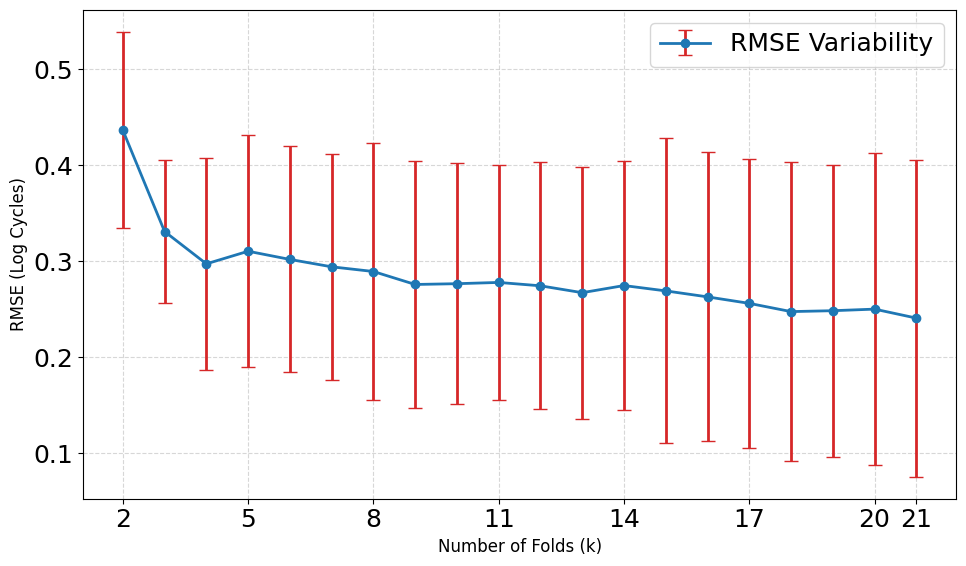

In [ ]:
def find_optimal_k(df, model_xgb, n_repeats=5):
    """
    Runs repeated CV for ALL possible K values (from 2 to N).
    Best for small datasets (N < 50).
    """
    N = len(df)
    k_candidates = range(2, N + 1) 
    
    results = {k: [] for k in k_candidates}
    
    print(f"Starting Exhaustive Stability Analysis (N={N} samples)...")
    
    for k in k_candidates:
        print(f"Processing K={k}...", end=" ")
        
        rkf = RepeatedKFold(n_splits=k, n_repeats=n_repeats, random_state=42)
        
        k_scores = []
        
        for train_idx, test_idx in rkf.split(df):
            train_fold = df.iloc[train_idx].copy()
            test_fold  = df.iloc[test_idx].copy()
            
            rmse = train_and_evaluate_fold(train_fold, test_fold, model_xgb, epochs=500)
            k_scores.append(rmse)
        
        results[k] = k_scores
        print(f"Mean RMSE: {np.mean(k_scores):.4f}")
        
    return results

stats = find_optimal_k(df, model_xgb, n_repeats=3)

def plot_stability(stats, tick_step=3):
    means = [np.mean(stats[k]) for k in stats]
    stds  = [np.std(stats[k]) for k in stats]
    ks    = list(stats.keys())

    plt.figure(figsize=(10, 6))
    
    plt.errorbar(
        ks, means, yerr=stds, fmt='-o', capsize=5,
        color='tab:blue', ecolor='tab:red',
        linewidth=2, label='RMSE Variability'
    )

    plt.xlabel("Number of Folds (k)", fontsize=12)
    plt.ylabel("RMSE (Log Cycles)", fontsize=12)

    tick_positions = ks[::tick_step]
    if ks[-1] not in tick_positions:
        tick_positions.append(ks[-1])

    plt.xticks(tick_positions)

    plt.grid(True, linestyle='--', alpha=0.5)

    plt.legend()
    plt.tight_layout()
    plt.show()


# --- PLOTTING(Continuous K) ---
# def plot_stability(stats):
#     means = [np.mean(stats[k]) for k in stats]
#     stds  = [np.std(stats[k]) for k in stats]
#     ks    = list(stats.keys())

#     plt.figure(figsize=(10, 6))
    
#     # Error Bar Plot
#     plt.errorbar(ks, means, yerr=stds, fmt='-o', capsize=5, 
#                  color='tab:blue', ecolor='tab:red', linewidth=2, label='RMSE Variability')
    
#     plt.xlabel("Number of Folds (k)", fontsize=12)
#     plt.ylabel("RMSE (Log Cycles)", fontsize=12)
#     plt.title(f"Stability Analysis (K=2 to {max(ks)})", fontsize=14)
    
#     # Ensure x-axis shows integers only
#     plt.xticks(ks) 
#     plt.grid(True, linestyle='--', alpha=0.5)
    
#     best_k_idx = np.argmin(stds)
#     best_k = ks[best_k_idx]
#     plt.annotate(f'Most Stable (k={best_k})', 
#                  xy=(best_k, means[best_k_idx]), 
#                  xytext=(60, 100),  # move the text 40 points above the marker
#                 textcoords='offset points',
#                 ha='center',
#                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8)
#     )
#     plt.legend()
#     plt.show()
    
plot_stability(stats)

Creating a table with all the possible K folds and the corresponding RMSE Values that allow us to choose the correct fold

In [ ]:
def make_k_table(stats):
    rows = []
    for k, scores in stats.items():
        rows.append({
            "k": k,
            "RMSE_mean": float(np.mean(scores)),
            "RMSE_std":  float(np.std(scores)),  
        })
    return pd.DataFrame(rows).sort_values("k").reset_index(drop=True)

k_table = make_k_table(stats)
print(k_table)

     k  RMSE_mean  RMSE_std
0    2   0.436579  0.102093
1    3   0.330945  0.074730
2    4   0.297252  0.110137
3    5   0.310389  0.120680
4    6   0.301860  0.117821
5    7   0.294154  0.117913
6    8   0.289267  0.133645
7    9   0.275753  0.128728
8   10   0.276562  0.125873
9   11   0.277871  0.122194
10  12   0.274358  0.128599
11  13   0.267188  0.131155
12  14   0.274624  0.129558
13  15   0.269066  0.158882
14  16   0.262822  0.150706
15  17   0.256060  0.150849
16  18   0.247481  0.156001
17  19   0.248408  0.152100
18  20   0.250057  0.162225
19  21   0.240704  0.165110


Plotting 

Function to visualize the Augmented data within a representative fold

In [40]:
def visualize_fold_augmentation(df_combined, fold_idx):
    """
    Robust Visualization using Tolerance-Based Grouping.
    """
    real = df_combined[df_combined["Source"] != "augmented"].copy()
    synth = df_combined[df_combined["Source"] == "augmented"]
    
    plt.figure(figsize=(8, 8))
    
    plt.scatter(synth["log cycles"], synth["Maximum stress"], 
                c='tab:blue', alpha=0.15, s=15, label='Augmented Data')
    plt.scatter(real["log cycles"], real["Maximum stress"], 
                c='red', marker = '^', s=120, edgecolors='k', linewidth=1.5, zorder=10, label='Real Training Data')
    
    real = assign_stress_levels(real, tolerance=15.0)
    
    g1 = real[real['stress_level_id'] == 1]
    g2 = real[real['stress_level_id'] == 2]
    
    if not g1.empty and not g2.empty:
        x1 = np.mean(np.log10(g1["Number of cycles"].values))
        y1 = np.mean(g1["Maximum stress"].values)
        x2 = np.mean(np.log10(g2["Number of cycles"].values))
        y2 = np.mean(g2["Maximum stress"].values)
        
        plt.scatter(x1, y1, c='green', marker='*', s=250, zorder=15, edgecolors='k', label='Centroids')
        plt.scatter(x2, y2, c='green', marker='*', s=250, zorder=15, edgecolors='k')

        slope = (y2 - y1) / (x2 - x1)
        intercept = y1 - slope * x1
    else:
        slope = 0
        intercept = real["Maximum stress"].mean()

    x_line = np.linspace(real["log cycles"].min(), synth["log cycles"].max(), 100)
    y_center = slope * x_line + intercept
    bound_95 = 74.41 

    y_upper = y_center + bound_95
    y_lower = y_center - bound_95

    plt.fill_between(x_line, y_lower, y_upper, color='tab:blue', alpha=0.1, label='95% Noise Bound')
    
    plt.plot(x_line, y_upper, color='tab:blue', linestyle=':', alpha=0.3)
    plt.plot(x_line, y_lower, color='tab:blue', linestyle=':', alpha=0.3)
    

    plt.xlabel(r"Log Cycles ($\log_{10}N$)")
    plt.ylabel("Maximum Stress (MPa)")
    plt.title(f"Fold {fold_idx+1}: Robust Centroid Connection")
    #plt.legend(loc='upper right', frameon=True)
    plt.grid(True, linestyle='--', alpha=0.4)
    ax = plt.gca()
    ax.margins(x=0.05, y=0.1) 
    ax.set_xticks([3, 4, 5, 6, 7])                     
    ax.set_xticklabels([r'$10^3$', r'$10^4$', r'$10^5$', r'$10^6$', r'$10^7$'])  
    #ax.set_yticks([150, 200, 250, 300, 350])
    plt.show()

In [41]:
def plot_augmented_stress_vs_temp(train_aug):
    """
    Plots Stress vs Predicted Temperature.
    Size: 8x8
    """
    synth = train_aug[train_aug["Source"] == "augmented"]

    plt.figure(figsize=(8, 8))
    
    plt.scatter(synth["Maximum stress"], synth["Predicted Temperature"], 
                c='tab:blue', marker='o', s=50, alpha=0.3, label='Trained XGBoost Predictions')
    
    plt.scatter(df_one["Maximum stress"], df_one["Stab Temp(degree C)"], 
                c='red', marker='^', s=120, edgecolors='k', linewidth=1.5, zorder=10, label='Experimental Data')
    
    plt.ylabel("Predicted Temperature (°C)", fontsize=18)
    plt.xlabel("Maximum Stress (MPa)", fontsize=18)
    plt.title("Stress vs. Predicted Temperature", fontsize=18)
    
    plt.legend(loc='upper left', frameon=True, fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.4)
    
    ax = plt.gca()
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.tick_params(axis='both', which='minor', labelsize=18)
    plt.axvline((delta_fl* 1487.8) / 100, color="red", ls="--", label="Fatigue strength")
    
    plt.tight_layout()
    plt.show()

Evaluation Metrics function. The evaluation metrics used in the analysis are as follows:
1. R^2; R squared ; Higher the value, closer to 1 is better
2. RMSE; Root mean squared error ; Lower the value the better

In [42]:
from sklearn.metrics import r2_score

def print_model_report_card(y_true, y_pred):
    """
    Calculates relative metrics to contextualize RMSE.
    Expects y_true and y_pred to be in Log10 scale.
    """
    rmse = np.sqrt(np.mean((y_pred - y_true)**2))
    
    factor_err = 10**rmse
    
    data_range = np.max(y_true) - np.min(y_true)
    nrmse = (rmse / data_range) * 100
    
    r2 = r2_score(y_true, y_pred)
    
    print("-" * 30)
    print("MODEL PERFORMANCE REPORT")
    print("-" * 30)
    print(f"RMSE (Log Units):      {rmse:.4f}")
    print(f"Avg Error Factor:      {factor_err:.2f}x (Life prediction is within factor of {factor_err:.1f})")
    print(f"Normalized RMSE:       {nrmse:.2f}% of data range")
    print(f"R² Score:              {r2:.4f}")
    print("-" * 30)
    
    if factor_err < 2.0:
        print("VERDICT: EXCELLENT (Within standard experimental scatter)")
    elif factor_err < 3.0:
        print("VERDICT: ACCEPTABLE (Standard for high-scatter)")
    else:
        print("VERDICT: HIGH ERROR (Model may be underfitting)")


Updated Functions for training the final PINN model with the correct K fold and data augmentation strategy

In the following functions execution we see a graph on the upper right part for the comparison between the physics loss and the data loss. The graph reflects the training phase, where the model is updating its internal weights while going through the training set. 
As we see from the graph, both the physics loss and data loss is going down. It means our data is physically consistent with the constraints. 

In [43]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

def run_final_pipeline(
    df,
    xgb_model,
    best_k,
    device,
    epochs=1000,
    lr=0.002,
    lam_phys=0.1,
    do_plots_first_fold=True
):
    """
    Trains a K-fold ensemble of PINNs and stores:
      - loss histories (data, phys, phys-share, TEST)
      - per-point physics violation on the augmented training set
      - training fold inputs (stress/temp/logN) for analysis
      - per-fold TRAIN/TEST metrics on log10 life: MSE, RMSE, MAE, R2

    Returns:
      ensemble_models, metrics_table
    """
    print(f"\nTraining Final Ensemble with K={best_k}")
    kf = KFold(n_splits=best_k, shuffle=True, random_state=42)

    ensemble_models = []
    metrics_rows = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(df)):
     
        train_fold = df.iloc[train_idx].copy()
        test_fold  = df.iloc[test_idx].copy()
        train_fold["Source"] = "real"

        train_aug = augment_training_data(train_fold)

        if "Run Out" in train_aug.columns:
            train_aug = train_aug[train_aug["Run Out"] != "yes"].copy()

        if "Run Out" in test_fold.columns:
            test_fold = test_fold[test_fold["Run Out"] != "yes"].copy()

        if do_plots_first_fold and fold == 0:
            print("Visualizing Augmentation for Fold 1...")
            visualize_fold_augmentation(train_aug, fold)

        train_aug["Predicted Temperature"] = xgb_model.predict(train_aug[["Maximum stress"]])
        if not test_fold.empty:
            test_fold["Predicted Temperature"] = xgb_model.predict(test_fold[["Maximum stress"]])

        if do_plots_first_fold and fold == 0:
            print("Visualizing Stress vs. Predicted Temperature for Fold 1...")
            plot_augmented_stress_vs_temp(train_aug)

        # -------------------------
        # Prepare TRAIN tensors
        # -------------------------
        X_train = train_aug[["Maximum stress", "Predicted Temperature"]].values
        y_train = train_aug["log cycles"].values.reshape(-1, 1)  # log10(N)

        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)

        X_tr_t = torch.tensor(X_train_s, dtype=torch.float32, device=device)
        y_tr_t = torch.tensor(y_train, dtype=torch.float32, device=device)

        # -------------------------
        # Prepare VALIDATION tensors
        # -------------------------
        X_te_t_val = None
        y_te_t_val = None
        if not test_fold.empty:
            X_test_val = test_fold[["Maximum stress", "Predicted Temperature"]].values
            y_test_val = test_fold["log cycles"].values.reshape(-1, 1)
            X_test_val_s = scaler.transform(X_test_val) # use same scaler
            X_te_t_val = torch.tensor(X_test_val_s, dtype=torch.float32, device=device)
            y_te_t_val = torch.tensor(y_test_val, dtype=torch.float32, device=device)

        # -------------------------
        # Train PINN
        # -------------------------
        model = LifeNet(hidden=64).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        hist_d, hist_p, hist_share, hist_test = [], [], [], []

        model.train()
        for _ in range(epochs):
            optimizer.zero_grad()
            pred = model(X_tr_t)

            loss_d = nn.MSELoss()(pred, y_tr_t)
            loss_p = physics_loss(model, X_tr_t)

            loss = loss_d + lam_phys * loss_p
            loss.backward()
            optimizer.step()

            hist_d.append(loss_d.item())
            hist_p.append(loss_p.item())

            # --- Validation Loss Tracking ---
            if X_te_t_val is not None:
                model.eval() # Switch to eval mode for validation
                with torch.no_grad():
                    pred_val = model(X_te_t_val)
                    loss_val = nn.MSELoss()(pred_val, y_te_t_val)
                    hist_test.append(loss_val.item())
                model.train() # Switch back to train mode
            else:
                hist_test.append(np.nan)

        # -------------------------
        # Metrics: TRAIN (logN)
        # -------------------------
        model.eval()
        with torch.no_grad():
            yhat_train = model(X_tr_t).detach().cpu().numpy().reshape(-1)
        ytrue_train = y_train.reshape(-1)

        train_mse  = mean_squared_error(ytrue_train, yhat_train)
        train_rmse = float(np.sqrt(train_mse))
        train_mae  = mean_absolute_error(ytrue_train, yhat_train)
        train_r2   = r2_score(ytrue_train, yhat_train)

        # -------------------------
        # Metrics: TEST (logN) on held-out real points
        # -------------------------
        if test_fold.empty:
            test_mse = test_rmse = test_mae = np.nan
            test_r2 = np.nan
        else:
            
            with torch.no_grad():
                yhat_test = model(X_te_t_val).detach().cpu().numpy().reshape(-1)
            y_test = y_te_t_val.detach().cpu().numpy().reshape(-1)

            test_mse  = mean_squared_error(y_test, yhat_test)
            test_rmse = float(np.sqrt(test_mse))
            test_mae  = mean_absolute_error(y_test, yhat_test)
            test_r2   = r2_score(y_test, yhat_test)

        ensemble_models.append({
            "model": model,
            "scaler": scaler,

            # histories
            "history_data": hist_d,
            "history_phys": hist_p,
            "history_test": hist_test,  

            # physics diagnostics
            "train_stress": train_aug["Maximum stress"].values,
            "train_temp": train_aug["Predicted Temperature"].values,
            "train_logN": train_aug["log cycles"].values,

            "train_mse": train_mse,
            "train_rmse": train_rmse,
            "train_mae": train_mae,
            "train_r2": train_r2,
            "test_mse": test_mse,
            "test_rmse": test_rmse,
            "test_mae": test_mae,
            "test_r2": test_r2,

            # metadata
            "fold_index": fold,
            "lam_phys": lam_phys,
            "epochs": epochs,
            "lr": lr
        })

        metrics_rows.append({
            "fold": fold + 1,
            "train_MSE(logN)": train_mse,
            "train_RMSE(logN)": train_rmse,
            "train_MAE(logN)": train_mae,
            "train_R2(logN)": train_r2,
            "test_MSE(logN)": test_mse,
            "test_RMSE(logN)": test_rmse,
            "test_MAE(logN)": test_mae,
            "test_R2(logN)": test_r2
        })

        print(f"Fold {fold+1}/{best_k} complete.")

    metrics_table = pd.DataFrame(metrics_rows)

    mean_row = {"fold": "mean"}
    std_row  = {"fold": "std"}
    for col in metrics_table.columns[1:]:
        mean_row[col] = metrics_table[col].mean()
        std_row[col]  = metrics_table[col].std(ddof=1) if len(metrics_table) > 1 else 0.0

    metrics_table = pd.concat([metrics_table, pd.DataFrame([mean_row, std_row])], ignore_index=True)

    return ensemble_models, metrics_table

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
import torch

def generate_final_report(df, ensemble_models, xgb_model, device="cpu", lam_phys=0.1):
    """
    Updated report that additionally supports:
      - Physics-share curve: (lam*L_phys) / (L_data + lam*L_phys)
      - TEST LOSS curve alongside training data loss
      - Physics compliance plot using *predicted temperature*
      - dlogN/dStress plotted in *physical units*
    """
    np.random.seed(42)
    k = len(ensemble_models)
    print(f"Generating Final Report for K={k} Ensemble...")

    def _mean_history(key):
        h_list = [np.asarray(m[key], dtype=float) for m in ensemble_models if key in m and len(m[key]) > 0]
        if not h_list:
            return None
        L = min(len(h) for h in h_list)
        H = np.vstack([h[:L] for h in h_list])
        return H.mean(axis=0)

    def _mean_history_if_exists(key):
        return _mean_history(key)

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    plt.subplots_adjust(hspace=0.35, wspace=0.3)

    # ===============================================================
    # 1) ACCURACY: Parity Plot (Top Left)
    # ===============================================================
    ax1 = axes[0, 0]
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    all_true, all_pred, all_stress = [], [], []

    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(df)):
        test_fold = df.iloc[test_idx].copy()
        if "Run Out" in test_fold.columns:
            test_fold = test_fold[test_fold["Run Out"] != "yes"].copy()
        if test_fold.empty:
            continue

        test_fold["Predicted Temperature"] = xgb_model.predict(test_fold[["Maximum stress"]])

        # Get model + scaler
        pack = ensemble_models[fold_idx]
        model, scaler = pack["model"], pack["scaler"]

        # Predict logN
        X_test = test_fold[["Maximum stress", "Predicted Temperature"]].values
        X_test_s = scaler.transform(X_test)
        X_test_t = torch.tensor(X_test_s, dtype=torch.float32, device=device)

        model.eval()
        with torch.no_grad():
            logN = model(X_test_t).detach().cpu().numpy().flatten()

        all_true.extend(test_fold["Number of cycles"].values)
        all_pred.extend(10 ** logN)
        all_stress.extend(test_fold["Maximum stress"].values)

    all_true = np.asarray(all_true, dtype=float)
    all_pred = np.asarray(all_pred, dtype=float)
    all_stress = np.asarray(all_stress, dtype=float)

    if len(all_true) == 0:
        print("Warning: No test predictions collected. Check your CV split / Run Out filtering.")
        return

    true_log = np.log10(all_true)
    pred_log = np.log10(all_pred)
    if "print_model_report_card" in globals():
        print_model_report_card(true_log, pred_log)

    sc = ax1.scatter(all_true, all_pred, c=all_stress, cmap="rainbow",
                     s=80, edgecolors="k", alpha=0.7)
    cbar = plt.colorbar(sc, ax=ax1)
    cbar.set_label("Stress (MPa)", fontsize=14)

    min_v = min(all_true.min(), all_pred.min())
    max_v = max(all_true.max(), all_pred.max())
    ax1.plot([min_v, max_v], [min_v, max_v], "r--", lw=2)

    ax1.set_xscale("log"); ax1.set_yscale("log")
    ax1.set_xticks([1e3, 1e4, 1e5, 1e6, 1e7])
    ax1.set_yticks([1e3, 1e4, 1e5, 1e6, 1e7])
    ax1.set_xlabel("True Cycles", fontsize=18)
    ax1.set_ylabel("Predicted Cycles", fontsize=18)
    ax1.set_title(f"Accuracy: Parity Plot (K={k})", fontsize=18)
    ax1.tick_params(axis="both", which="major", labelsize=18)
    ax1.tick_params(axis="both", which="minor", labelsize=18)
    ax1.grid(True, which="both", alpha=0.3)

    
    # ===============================================================
    # 2) TRAINING DYNAMICS: Loss + Physics (Top Right)
    # ===============================================================
    ax2 = axes[0, 1]

    hist_d_mean = _mean_history_if_exists("history_data")
    hist_p_mean = _mean_history_if_exists("history_phys")
    hist_t_mean = _mean_history_if_exists("history_test")      

    if hist_d_mean is None or hist_p_mean is None:
        hist_d_mean = np.asarray(ensemble_models[0].get("history_data", []), dtype=float)
        hist_p_mean = np.asarray(ensemble_models[0].get("history_phys", []), dtype=float)

    def smooth(y, box_pts=20):
        if len(y) < box_pts: return y
        box = np.ones(box_pts)/box_pts
        y_smooth = np.convolve(y, box, mode='same')
        y_smooth[:box_pts] = y[:box_pts]
        return y_smooth

    epochs_axis = np.arange(len(hist_d_mean))

    ax2.plot(epochs_axis, hist_d_mean, color='#1f77b4', alpha=0.15, linewidth=1) 

    ax2.plot(epochs_axis, smooth(hist_d_mean), label="Train Loss (Data)", 
             color='#1f77b4', linewidth=2.5)

    # 2. Test Data Loss
    if hist_t_mean is not None:
        ax2.plot(epochs_axis, hist_t_mean, color='#ff7f0e', alpha=0.15, linewidth=1)
        ax2.plot(epochs_axis, smooth(hist_t_mean), label="Test Loss (Data)", 
                 color='#ff7f0e', linewidth=2.5, linestyle="--")


    w_phys = lam_phys * hist_p_mean
    ax2.plot(epochs_axis, w_phys, color='#2ca02c', alpha=0.15, linewidth=1)
    ax2.plot(epochs_axis, smooth(w_phys), label="Train Loss (Physics)", 
             color='#2ca02c', linewidth=2.5, linestyle="-.")

    ax2.set_yscale("log")
    ax2.set_xlabel("Epochs", fontsize=18, fontweight='bold', color='#333333')
    ax2.set_ylabel("Loss", fontsize=18, fontweight='bold', color='#333333')
    ax2.set_title("Training Dynamics", fontsize=18, pad=10)
    
    # Improved Grid (Major and Minor)
    ax2.grid(True, which="major", linestyle='-', alpha=0.6, color='#dddddd')
    ax2.grid(True, which="minor", linestyle=':', alpha=0.4, color='#eeeeee')
    
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    
    ax2.legend(fontsize=11, loc="upper right", framealpha=0.9, fancybox=True, edgecolor="#cccccc")
    
    ax2.tick_params(axis="both", which="major", labelsize=12)

    # ===============================================================
    # 3) PHYSICS CHECK: dlogN/dStress in physical units (Bottom Left)
    # ===============================================================
    ax3 = axes[1, 0]

    min_stress = df["Maximum stress"].min()
    max_stress = df["Maximum stress"].max()

    stress_range = np.linspace(min_stress * 0.9, max_stress * 1.1, 120).reshape(-1, 1)
    temp_pred = xgb_model.predict(pd.DataFrame(stress_range, columns=["Maximum stress"])).reshape(-1, 1)
    X_raw = np.column_stack([stress_range, temp_pred])  # [stress, temp]

    for i, pack in enumerate(ensemble_models):
        model, scaler = pack["model"], pack["scaler"]

        X_s = scaler.transform(X_raw)
        X_t = torch.tensor(X_s, dtype=torch.float32, device=device, requires_grad=True)

        model.eval()
        pred = model(X_t)

        grads = torch.autograd.grad(pred, X_t, torch.ones_like(pred),
                                    create_graph=False, retain_graph=False)[0]

        std_stress = float(scaler.scale_[0]) if hasattr(scaler, "scale_") else 1.0
        dlogN_dStress_phys = (grads[:, 0].detach().cpu().numpy() / std_stress)

        ax3.plot(stress_range.flatten(), dlogN_dStress_phys,
                 alpha=0.35, linewidth=2,
                 label=("Ensemble members" if i == 0 else None))

    ax3.axhline(0.0, color="red", linestyle="--", lw=2, label="Monotonicity limit (0)")
    ax3.set_xlabel("Stress (MPa)", fontsize=18)
    ax3.set_ylabel(r"$\partial \log_{10}N / \partial \sigma$ (per MPa)", fontsize=16)
    ax3.set_title("Physics Compliance", fontsize=18)
    ax3.tick_params(axis="both", which="major", labelsize=14)
    ax3.grid(True, alpha=0.3)
    ax3.legend(fontsize=10)

    # ===============================================================
    # 4) OVERALL FIT: S–N Curve (Bottom Right)
    # ===============================================================
    ax4 = axes[1, 1]

    np_true = all_true.copy()
    np_pred = all_pred.copy()
    np_stress = all_stress.copy()

    # Trend on log10(true cycles) vs stress
    regr = LinearRegression()
    regr.fit(np_stress.reshape(-1, 1), np.log10(np_true))

    smooth_stress = np.linspace(np_stress.min() * 0.95, np_stress.max() * 1.05, 120)
    trend_log_smooth = regr.predict(smooth_stress.reshape(-1, 1))
    trend_cycles_smooth = 10 ** trend_log_smooth

    # Bands (factor bands)
    factors = [4, 3, 2]
    colors_band = ["#E0E0E0", "#C0C0C0", "#A0A0A0"]
    alphas = [0.4, 0.5, 0.6]
    labels_band = ["4× band", "3× band", "2× band"]

    for factor, color, alpha, label in zip(factors, colors_band, alphas, labels_band):
        upper_band = trend_cycles_smooth * factor
        lower_band = trend_cycles_smooth / factor
        ax4.fill_betweenx(smooth_stress, lower_band, upper_band,
                          color=color, alpha=alpha, label=label, edgecolor="none")

    ax4.plot(trend_cycles_smooth, smooth_stress, "k--", alpha=0.9, label="Mean True Trend", linewidth=1.5)

    ax4.scatter(np_true, np_stress, c="red", marker='^', s=100, edgecolors="k",
                label="True Data", zorder=10)
    ax4.scatter(np_pred, np_stress, c="tab:blue", marker="o", s=80, alpha=0.8, edgecolors="k",
                label="Predicted", zorder=11)

    rmse_log = np.sqrt(np.mean((np.log10(np_true) - np.log10(np_pred)) ** 2))
    avg_error_factor = 10 ** rmse_log

    ax4.set_xscale("log")
    ax4.set_xlabel(r"Cycles ($N_f$)", fontsize=18)
    ax4.set_ylabel("Stress (MPa)", fontsize=18)
    ax4.set_title("Global S-N Curve", fontsize=18)
    ax4.tick_params(axis="both", which="major", labelsize=14)
    ax4.legend(loc="upper right", framealpha=0.95, facecolor="white", edgecolor="lightgrey", fontsize=10)
    ax4.grid(True, which="both", ls="-", alpha=0.2)

    ax4.text(0.05, 0.05,
             f"Avg Error Factor: {avg_error_factor:.2f}×",
             transform=ax4.transAxes,
             bbox={"facecolor": "white", "alpha": 0.9, "pad": 5, "edgecolor": "black"},
             fontsize=12, fontweight="bold")

    plt.tight_layout()
    plt.show()

We plotted 4 different plots to see how the model is performing. Following are the description of each:
1. Parity Plot between predicted vs true cycles
2. Training Dynamics (How the loss evolves)
3. Physics Compliance of each fold
4. Global S-N Curve

Global Random Seed set to: 41

Training Final Ensemble with K=21
Standard Deviation (1 sigma): 32.27
95% Confidence Bound:        74.41
Actual noise within bound:   97.50%
Visualizing Augmentation for Fold 1...


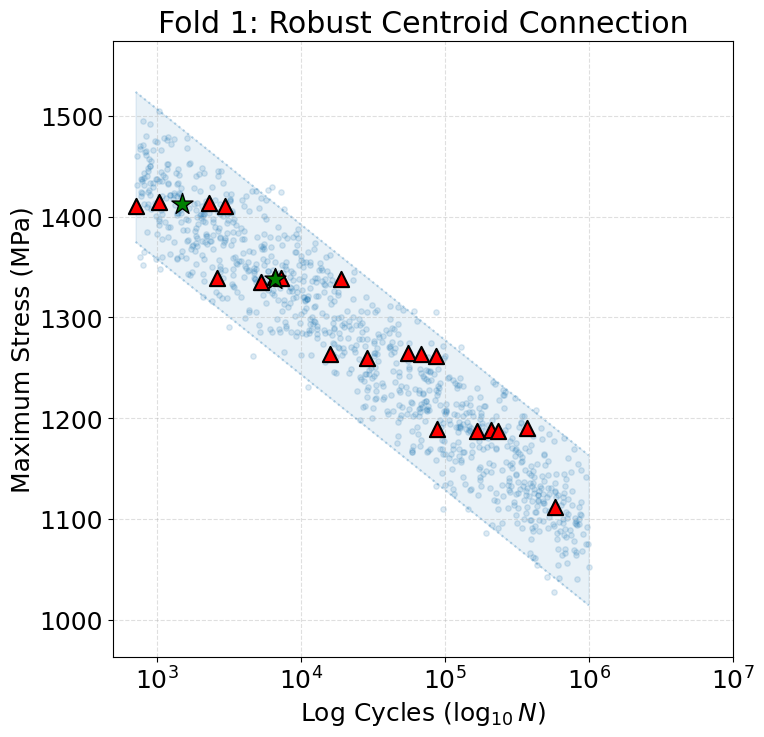

Visualizing Stress vs. Predicted Temperature for Fold 1...


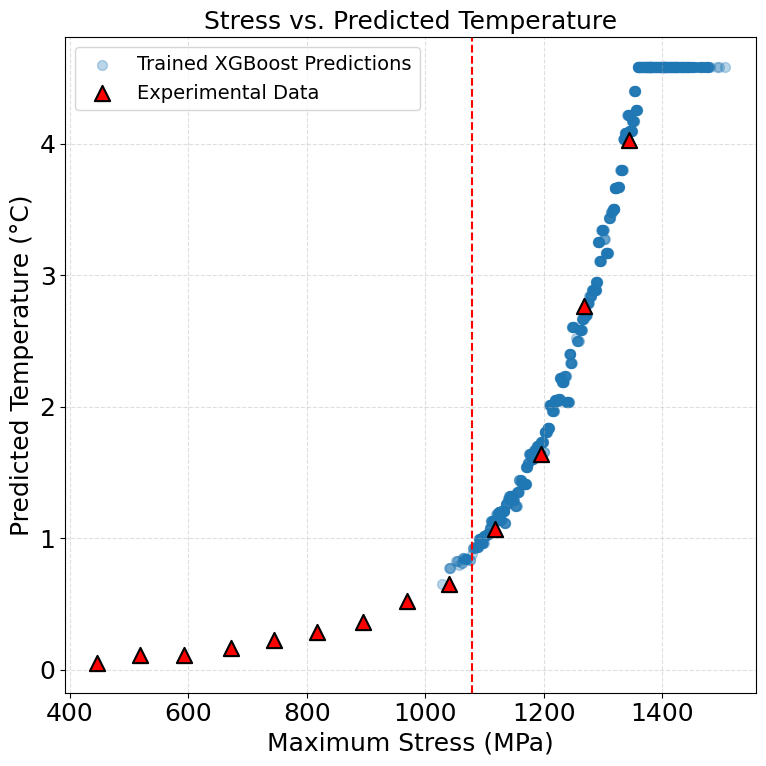

/Users/gauravsharma/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


Fold 1/21 complete.
Standard Deviation (1 sigma): 29.49
95% Confidence Bound:        66.72
Actual noise within bound:   97.80%


/Users/gauravsharma/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


Fold 2/21 complete.
Standard Deviation (1 sigma): 29.49
95% Confidence Bound:        66.72
Actual noise within bound:   98.00%


/Users/gauravsharma/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


...

/Users/gauravsharma/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


Fold 19/21 complete.
Standard Deviation (1 sigma): 29.49
95% Confidence Bound:        66.72
Actual noise within bound:   97.00%


/Users/gauravsharma/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


Fold 20/21 complete.
Standard Deviation (1 sigma): 29.55
95% Confidence Bound:        68.14
Actual noise within bound:   98.40%
Fold 21/21 complete.


/Users/gauravsharma/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [45]:
import random 
def set_seed(seed=42):
    """
    Locks the random state for Python, NumPy, and PyTorch.
    Ensures that augmentation, weight initialization, and data splits are identical every run.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f"Global Random Seed set to: {seed}")
set_seed(41)

ensemble_models, metrics_table = run_final_pipeline(
    df=df,
    xgb_model=model_xgb,
    best_k=21,      
    device=device,
    epochs=1000,          
    lr=0.002,
    lam_phys=0.1,
    do_plots_first_fold=True  
)


Generating Final Report for K=21 Ensemble...
------------------------------
MODEL PERFORMANCE REPORT
------------------------------
RMSE (Log Units):      0.2954
Avg Error Factor:      1.97x (Life prediction is within factor of 2.0)
Normalized RMSE:       9.99% of data range
R² Score:              0.8933
------------------------------
VERDICT: EXCELLENT (Within standard experimental scatter)


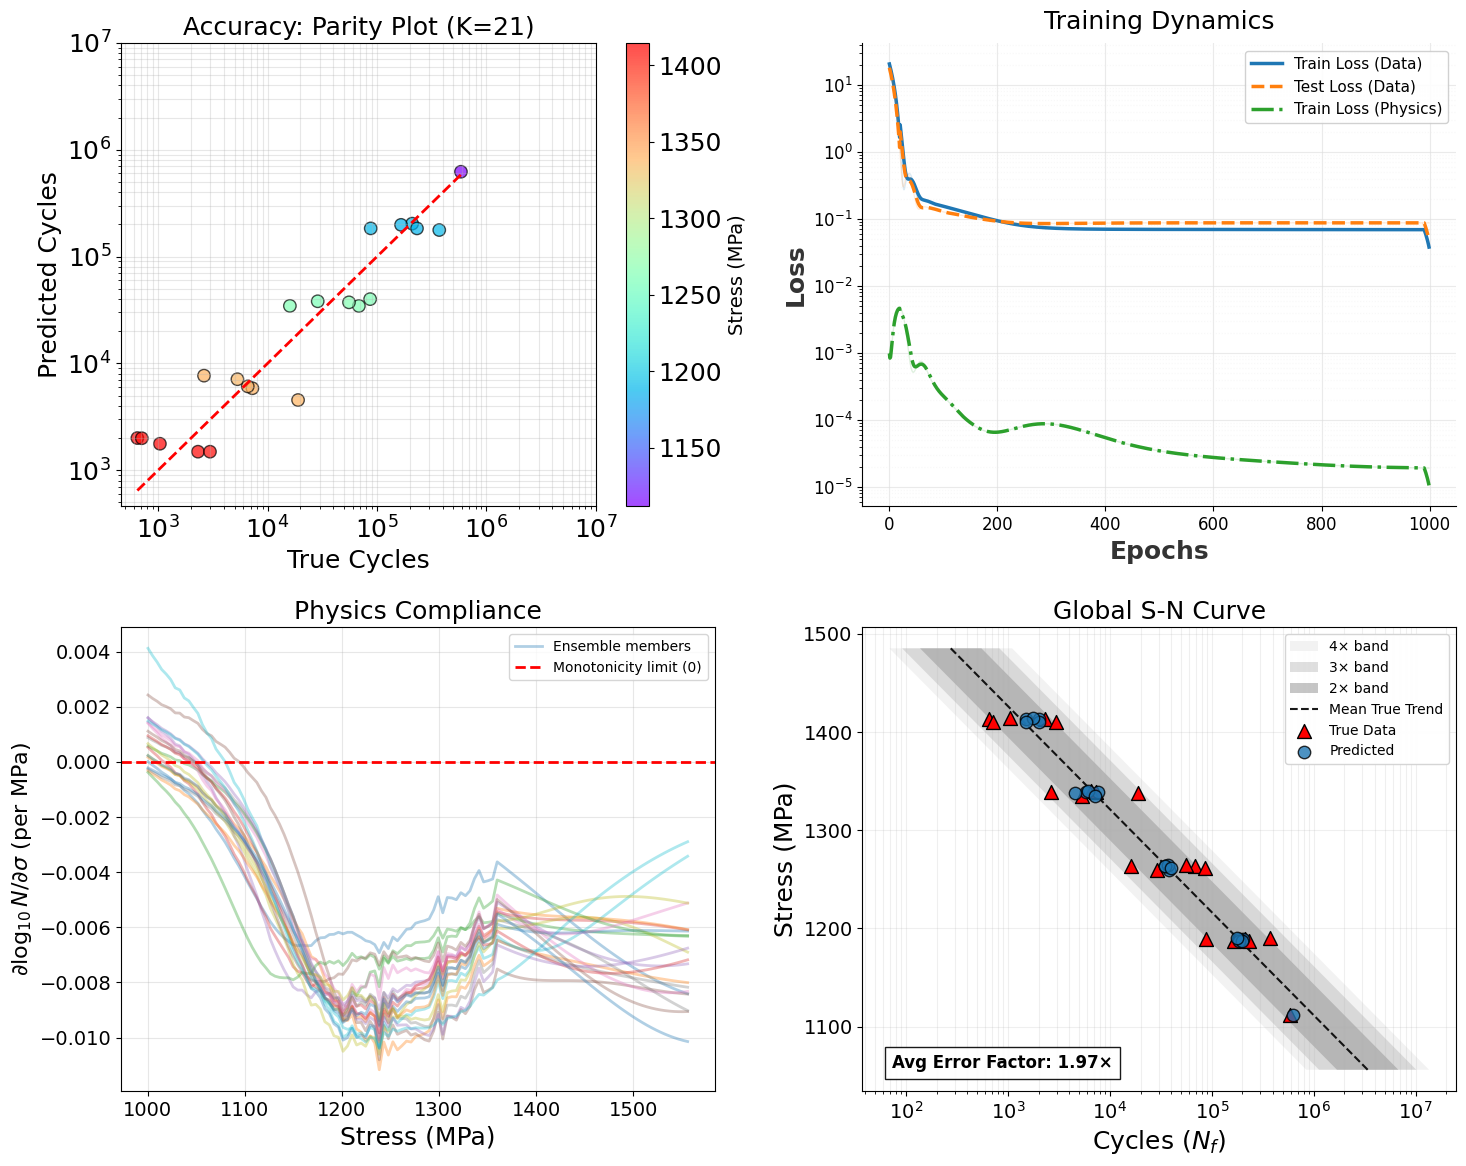

In [46]:
generate_final_report(df, ensemble_models, model_xgb,device=device,lam_phys=0.1)

In [ ]:
def plot_sn_curve_with_bands_vibrant(df, ensemble_models, xgb_model, device='cpu'):
    """
    Generates a standalone S-N Curve plot with GRAYSCALE 2x, 3x, and 4x error bands
    and Dynamic Axis Ticks based on the dataset range.
    """
    np.random.seed(42)
    k = len(ensemble_models)
    print(f"Generating Grayscale S-N Curve for K={k} Ensemble...")

    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    all_true, all_pred, all_stress = [], [], []

    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(df)):
        test_fold = df.iloc[test_idx].copy()
        test_fold["Predicted Temperature"] = xgb_model.predict(test_fold[["Maximum stress"]])
        
        pack = ensemble_models[fold_idx]
        model, scaler = pack["model"], pack["scaler"]
        
        X_test = test_fold[["Maximum stress", "Predicted Temperature"]].values
        X_test_s = scaler.transform(X_test)
        X_test_t = torch.tensor(X_test_s, dtype=torch.float32, device=device)
        
        model.eval()
        with torch.no_grad():
            logN = model(X_test_t).cpu().numpy().flatten()
            
        all_true.extend(test_fold["Number of cycles"].values)
        all_pred.extend(10**logN)
        all_stress.extend(test_fold["Maximum stress"].values)

    np_true = np.array(all_true)
    np_pred = np.array(all_pred)
    np_stress = np.array(all_stress)

    regr = LinearRegression()
    regr.fit(np_stress.reshape(-1, 1), np.log10(np_true))
    
    smooth_stress = np.linspace(np_stress.min()*0.95, np_stress.max()*1.05, 100)
    trend_log_smooth = regr.predict(smooth_stress.reshape(-1, 1))
    trend_cycles_smooth = 10**trend_log_smooth
    
    factors = [4, 3, 2] 
    colors = ['#E0E0E0', '#C0C0C0', '#A0A0A0'] 
    labels = ['4x Factor (Outer)', '3x Factor', '2x Factor (Inner)']
    alphas = [0.4, 0.5, 0.6]

    plt.figure(figsize=(10, 7))
    
    for factor, color, alpha, label in zip(factors, colors, alphas, labels):
        upper_band = trend_cycles_smooth * factor
        lower_band = trend_cycles_smooth / factor
        plt.fill_betweenx(smooth_stress, lower_band, upper_band, 
                          color=color, alpha=alpha, label=label, edgecolor='none')

    plt.plot(trend_cycles_smooth, smooth_stress, 'k--', alpha=0.8, label='Mean True Trend', linewidth=1.5)

    plt.scatter(np_true, np_stress, marker='^', color='red', s=80, label='True Data', zorder=10, linewidth=1.5, edgecolors="k")
    plt.scatter(np_pred, np_stress, marker='o', color='blue', s=60, label='Predicted', alpha=1.0, zorder=11, edgecolors='k', linewidth=0.5)

    log_true = np.log10(np_true)
    log_pred = np.log10(np_pred)
    rmse_log = np.sqrt(np.mean((log_true - log_pred)**2))
    avg_error_factor = 10**rmse_log

    plt.xscale('log')
    ax = plt.gca()

    min_val = min(np_true.min(), np_pred.min())
    max_val = max(np_true.max(), np_pred.max())
    
    start_exp = np.floor(np.log10(min_val))
    end_exp = np.ceil(np.log10(max_val))
    
    ax.margins(x=0.05, y=0.1)

    # Labels
    plt.xlabel('Cycles ($N_f$)', fontsize=12, fontweight='bold')
    plt.ylabel('Stress (MPa)', fontsize=12, fontweight='bold')
    plt.title('Global S-N Curve with Grayscale Scatter Bands', fontsize=14, fontweight='bold')
    plt.grid(True, which="both", ls="-", color='lightgrey', alpha=0.4)

    # Legend
    legend = plt.legend(loc='upper right', framealpha=1, facecolor='white', edgecolor='black', fontsize=10, shadow=True)
    frame = legend.get_frame()
    frame.set_linewidth(1.0)

    plt.figtext(0.15, 0.15, 
                f"Avg Error Factor: {avg_error_factor:.2f}x", 
                bbox={'facecolor':'white', 'alpha':1.0, 'pad':6, 'edgecolor':'black', 'boxstyle':'round,pad=0.5'}, 
                fontsize=11, fontweight='bold')
    plt.xlim(1e2, 1e8)
    plt.ylim(df["Maximum stress"].min()-20, df["Maximum stress"].max()+20)
    plt.tight_layout()
    plt.show()

Generating Grayscale S-N Curve for K=21 Ensemble...


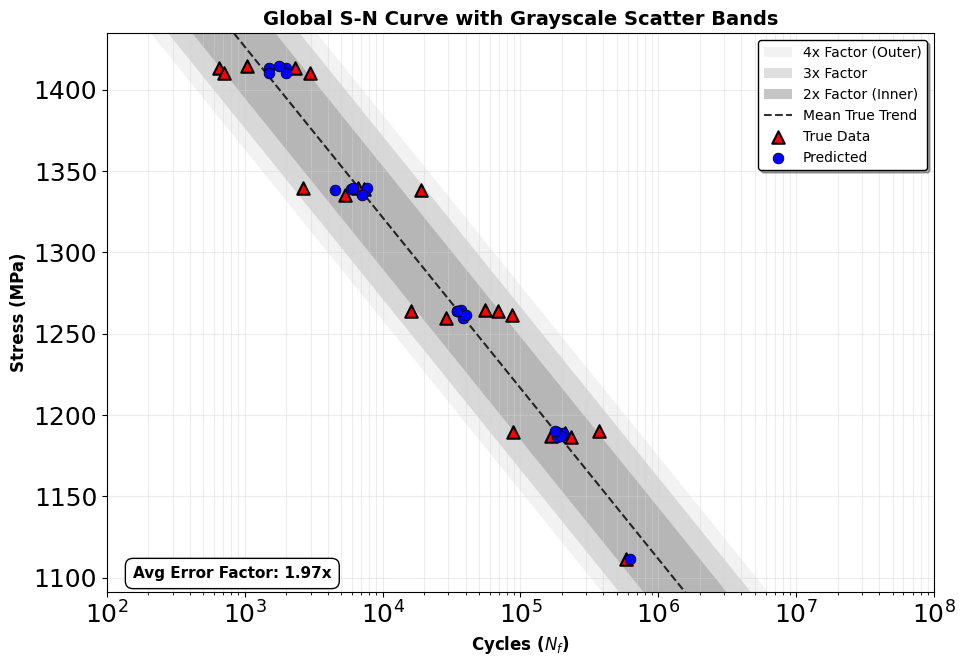

In [ ]:
plot_sn_curve_with_bands_vibrant(df, ensemble_models, model_xgb, device=device)

Ghost Training function 

We try to implement and create a graph overlaying both models, one trained without the physics loss and another trained on physics loss

In [ ]:
def train_ghost_model(df, xgb_model,best_k):
    print("Training 'Ghost' Model (Physics Weight = 0.0)...")
    
    kf = KFold(n_splits=best_k, shuffle=True, random_state=42) 
    train_idx, test_idx = next(kf.split(df)) 
    
    train_fold = df.iloc[train_idx].copy()
    
    train_aug = augment_training_data(train_fold)
    train_aug["Predicted Temperature"] = xgb_model.predict(train_aug[["Maximum stress"]])
    
    X_train = train_aug[["Maximum stress", "Predicted Temperature"]].values
    y_train = train_aug["log cycles"].values.reshape(-1, 1)
    
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_tr_t = torch.tensor(X_train_s, dtype=torch.float32, device=device)
    y_tr_t = torch.tensor(y_train, dtype=torch.float32, device=device)
    
    model = LifeNet(hidden=64).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
    
    model.train()
    for _ in range(1000):
        optimizer.zero_grad()
        pred = model(X_tr_t)
        loss = nn.MSELoss()(pred, y_tr_t) + 0.0 * physics_loss(model, X_tr_t) 
        loss.backward()
        optimizer.step()
        
    return {"model": model, "scaler": scaler}

ghost_package = train_ghost_model(df, model_xgb,best_k=21)

Training 'Ghost' Model (Physics Weight = 0.0)...
Standard Deviation (1 sigma): 32.27
95% Confidence Bound:        74.41
Actual noise within bound:   97.80%


Comparing Derivatives: PINN vs Ghost...


<Figure size 800x500 with 0 Axes>

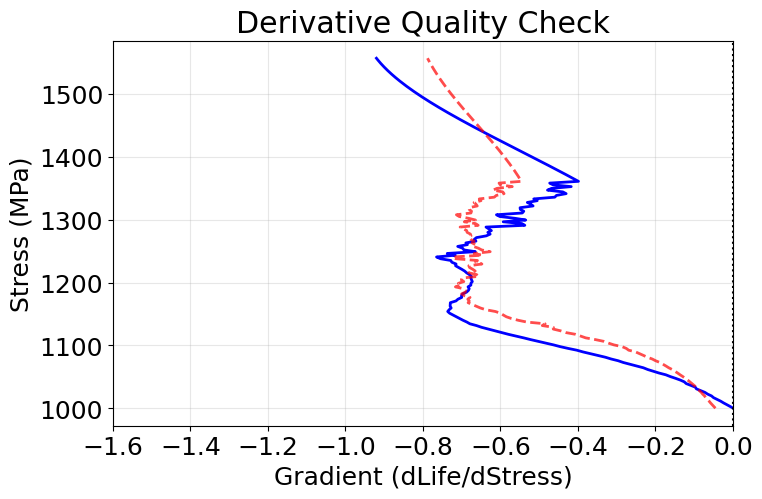

In [ ]:
def compare_model_derivatives(df,xgb_model, pinn_package, ghost_package, device):
    print("Comparing Derivatives: PINN vs Ghost...")
    
    min_stress = df["Maximum stress"].min() * 0.9
    max_stress = df["Maximum stress"].max() * 1.1
    
    stress_range = np.linspace(min_stress, max_stress, 200).reshape(-1, 1)
    temp_df = pd.DataFrame(stress_range, columns=["Maximum stress"])
    temp_range = xgb_model.predict(temp_df).reshape(-1, 1)
    
    X_raw = np.column_stack([stress_range, temp_range])
    
    model_p, scaler_p = pinn_package[0]["model"], pinn_package[0]["scaler"]
    X_s_p = scaler_p.transform(X_raw)
    X_t_p = torch.tensor(X_s_p, dtype=torch.float32, device=device, requires_grad=True)
    
    model_p.eval()
    pred_p = model_p(X_t_p)
    grads_p = torch.autograd.grad(pred_p, X_t_p, torch.ones_like(pred_p), create_graph=False)[0]
    deriv_pinn = grads_p[:, 0].cpu().detach().numpy()
    
    model_g, scaler_g = ghost_package["model"], ghost_package["scaler"]
    X_s_g = scaler_g.transform(X_raw)
    X_t_g = torch.tensor(X_s_g, dtype=torch.float32, device=device, requires_grad=True)
    
    model_g.eval()
    pred_g = model_g(X_t_g)
    grads_g = torch.autograd.grad(pred_g, X_t_g, torch.ones_like(pred_g), create_graph=False)[0]
    deriv_ghost = grads_g[:, 0].cpu().detach().numpy()

    plt.figure(figsize=(8, 5))
    plt.figure(figsize=(8, 5))
    plt.plot(deriv_pinn, stress_range, 'b-', linewidth=2, label='PINN Derivative')
    plt.plot(deriv_ghost, stress_range, 'r--', linewidth=2, alpha=0.7, label='Ghost Derivative')
 
    plt.axvline(0, color='k', linestyle=':', label='Zero Line')
 
    plt.xlabel('Gradient (dLife/dStress)')
    plt.xlim(-1.6, 0)
    plt.ylabel('Stress (MPa)')
    plt.title('Derivative Quality Check')
    plt.grid(True, alpha=0.3)
    plt.show()

compare_model_derivatives(df,model_xgb, ensemble_models, ghost_package, device)

Running the No physics model to check how the predictions vary when we include the physics loss terms 

In [ ]:
def train_no_physics_model(df, xgb_model, k_folds=21):
    print(f"Training 'Pure Data' Model (Physics Weight = 0.0) using K={k_folds}...")
    
    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    train_idx, test_idx = next(kf.split(df))
    
    train_fold = df.iloc[train_idx].copy()
    
    train_aug = augment_training_data(train_fold)
    train_aug["Predicted Temperature"] = xgb_model.predict(train_aug[["Maximum stress"]])
    
    # 2. Prepare Data
    X_train = train_aug[["Maximum stress", "Predicted Temperature"]].values
    y_train = train_aug["log cycles"].values.reshape(-1, 1)
    
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_tr_t = torch.tensor(X_train_s, dtype=torch.float32, device=device)
    y_tr_t = torch.tensor(y_train, dtype=torch.float32, device=device)
    
    # 3. Train
    model = LifeNet(hidden=64).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
    
    model.train()
    for _ in range(1000): # Same epochs
        optimizer.zero_grad()
        pred = model(X_tr_t)
        loss = nn.MSELoss()(pred, y_tr_t) + 0.0 * physics_loss(model, X_tr_t)
       
        
        loss.backward()
        optimizer.step()
        
    return {"model": model, "scaler": scaler}

In [ ]:
def visualize_predictions_comparison(df, pinn_ensemble, no_phys_package, xgb_model, device='cpu'):
    print("Generating Prediction Overlay: PINN vs No-Physics...")
    
    # 1. Get Models
    pinn_model = pinn_ensemble[0]["model"]
    pinn_scaler = pinn_ensemble[0]["scaler"]
    
    np_model = no_phys_package["model"]
    np_scaler = no_phys_package["scaler"]
    
    min_stress = df["Maximum stress"].min() 
    max_stress = df["Maximum stress"].max() 
    
    stress_range = np.linspace(min_stress, max_stress, 200).reshape(-1, 1)
    
    temp_df = pd.DataFrame(stress_range, columns=["Maximum stress"])
    temp_pred = xgb_model.predict(temp_df).reshape(-1, 1)
    
    X_grid = np.column_stack([stress_range, temp_pred])
    
    # 3. Predict: PINN
    X_pinn_s = pinn_scaler.transform(X_grid)
    X_pinn_t = torch.tensor(X_pinn_s, dtype=torch.float32, device=device)
    pinn_model.eval()
    with torch.no_grad():
        logN_pinn = pinn_model(X_pinn_t).cpu().numpy().flatten()

    # 4. Predict: No-Physics
    X_np_s = np_scaler.transform(X_grid)
    X_np_t = torch.tensor(X_np_s, dtype=torch.float32, device=device)
    np_model.eval()
    with torch.no_grad():
        logN_np = np_model(X_np_t).cpu().numpy().flatten()
        
    plt.figure(figsize=(10, 7))
    
    # Real Data
    plt.scatter(df["Number of cycles"], df["Maximum stress"], 
                c='red', marker='^', s=80, label='Experimental Data', zorder=10)
    
    # PINN Prediction (Blue Solid)
    plt.plot(10**logN_pinn, stress_range, 
             'b-', linewidth=2.5, label='PINN (With Physics)')
    
    # No-Physics Prediction (Red Dashed)
    plt.plot(10**logN_np, stress_range, 
             'k--', linewidth=2, label='Standard NN (No Physics)')
    
    plt.xscale('log')
    plt.xlabel('Cycles to Failure ($N_f$)', fontsize=12)
    plt.ylabel('Stress (MPa)', fontsize=12)
    plt.title('Impact of Physics Loss on Predictions', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, which="both", alpha=0.3)
    
    plt.tight_layout()
    plt.xlim(1e2, 1e8)
    plt.ylim(950,1500)
    plt.show()

The following scatter plot shows how the predictions look like. The jitters or wobbly line we see is from the temperature prediction, as we used the xgboost model to predict the temp for correspomdomg stress values. Number of cycles is highly sensitive to the temperature. And also, xgboost does not give a smooth curve, rather it gives a stepwise graph as we can observe from the plot as well 

In [ ]:
# 1. Train the single "No Physics" model
no_phys_model = train_no_physics_model(df, model_xgb, k_folds=21)

# 2. Visualize the difference
visualize_predictions_comparison(df, ensemble_models, no_phys_model, model_xgb)

Baseline Comparison 

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=5,
        random_state=42
    ),

    "SVR (RBF)": make_pipeline(
        StandardScaler(),
        SVR(C=10, epsilon=0.25, kernel='rbf')
    ),

    "SVR (RBF V2)": make_pipeline(
        StandardScaler(),
        SVR(C=1, epsilon=0.9, kernel='rbf')
    ),

    "SVR (POLY)": make_pipeline(
        StandardScaler(),
        SVR(C=1, epsilon=0.5, kernel='poly')
    ),

    "MLP": MLPRegressor(
        hidden_layer_sizes=(32,16),
        max_iter=2000,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [51]:
results = []

global_predictions = {}

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

kf = KFold(n_splits=21, shuffle=True, random_state=42)

for model_name, model in models.items():

    all_true = []
    all_pred = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(df)):

        train_df = df.iloc[train_idx].copy()
        test_df = df.iloc[test_idx].copy()

        # Temperature prediction
        train_df["Predicted Temperature"] = model_xgb.predict(
            train_df[["Maximum stress"]]
        )

        test_df["Predicted Temperature"] = model_xgb.predict(
            test_df[["Maximum stress"]]
        )

        X_train = train_df[[
            "Maximum stress",
            "Predicted Temperature"
        ]]

        X_test = test_df[[
            "Maximum stress",
            "Predicted Temperature"
        ]]

        y_train = train_df["log cycles"]
        y_test = test_df["log cycles"]

        # Train
        model.fit(X_train, y_train)

        # Predict
        preds = model.predict(X_test)

        # Store globally
        all_true.extend(y_test.values)
        all_pred.extend(preds)

    # Convert
    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    # GLOBAL metrics
    mse = mean_squared_error(all_true, all_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(all_true, all_pred)
    r2 = r2_score(all_true, all_pred)

    results.append({
        "Model": model_name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

    global_predictions[model_name] = {
        "y_true": all_true,
        "y_pred": all_pred
    }

all_true_pinn = []
all_pred_pinn = []

kf = KFold(n_splits=21, shuffle=True, random_state=42)

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(df)):

    test_fold = df.iloc[test_idx].copy()

    test_fold["Predicted Temperature"] = model_xgb.predict(
        test_fold[["Maximum stress"]]
    )

    pack = ensemble_models[fold_idx]

    model = pack["model"]
    scaler = pack["scaler"]

    X_test = test_fold[[
        "Maximum stress",
        "Predicted Temperature"
    ]].values

    X_test_s = scaler.transform(X_test)

    X_test_t = torch.tensor(
        X_test_s,
        dtype=torch.float32,
        device=device
    )

    model.eval()

    with torch.no_grad():
        preds = model(X_test_t).cpu().numpy().flatten()

    y_true = test_fold["log cycles"].values

    all_true_pinn.extend(y_true)
    all_pred_pinn.extend(preds)

# Convert
all_true_pinn = np.array(all_true_pinn)
all_pred_pinn = np.array(all_pred_pinn)

# GLOBAL PINN metrics
mse = mean_squared_error(all_true_pinn, all_pred_pinn)
rmse = np.sqrt(mse)
mae = mean_absolute_error(all_true_pinn, all_pred_pinn)
r2 = r2_score(all_true_pinn, all_pred_pinn)

results.append({
    "Model": "PINN",
    "MSE": mse,
    "RMSE": rmse,
    "MAE": mae,
    "R2": r2
})

global_predictions["PINN"] = {
    "y_true": all_true_pinn,
    "y_pred": all_pred_pinn
}


/Users/gauravsharma/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/gauravsharma/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/gauravsharma/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/gauravsharma/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/gauravsharma/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/gauravsharma/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/gauravsharma/miniconda3/lib/python3.12/site-packages/sklearn/util

In [52]:
results_df = pd.DataFrame(results)

results_df = results_df.round(4)

print(results_df)

           Model      MSE    RMSE     MAE       R2
0  Random Forest   0.1558  0.3947  0.3579   0.8094
1      SVR (RBF)   0.1544  0.3929  0.3118   0.8111
2   SVR (RBF V2)   0.3489  0.5907  0.4947   0.5732
3     SVR (POLY)   0.5245  0.7242  0.4747   0.3583
4            MLP  31.7147  5.6316  5.5623 -37.8014
5        XGBoost   0.2864  0.5352  0.4574   0.6496
6           PINN   0.0872  0.2954  0.2442   0.8933


In [53]:
results_df.to_csv("Baseline_model_comparison_Huang.csv", index=False)